# ScholarRAG — Evaluation Dashboard (Post-Fix, Strict-Grounding)

Comprehensive post-fix visualizations for targeted retrieval/abstention validation, strict-grounding faithfulness/coverage tradeoffs, leakage-aware M/S/A calibration, fresh IAA, cross-corpus generalization, and formal significance tests.


In [1]:
import json, csv, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", font_scale=1.15)
PAL = ["#FF6F00", "#FFA000", "#FFD54F", "#4FC3F7", "#0288D1", "#01579B", "#E65100"]
sns.set_palette(PAL)

DATA = pathlib.Path("data")
POST = DATA / "post_fix/benchmark_56_strict"
BASE = DATA / "post_fix/benchmark_56_baseline_before_strict"

post_validation = json.loads((DATA / "post_fix/post_fix_validation.json").read_text())
faith = json.loads((POST / "faithfulness_distribution.json").read_text())
faith_base = json.loads((BASE / "faithfulness_distribution.json").read_text())
calib = json.loads((POST / "calibration_robustness.json").read_text())
calib_base = json.loads((BASE / "calibration_robustness.json").read_text())
headline = json.loads((POST / "headline_metrics.json").read_text())
headline_base = json.loads((BASE / "headline_metrics.json").read_text())
judge_raw = json.loads((POST / "judge_eval_post_fix.json").read_text())
judge_base = json.loads((BASE / "judge_eval_post_fix.json").read_text())
iaa_fresh = json.loads((DATA / "post_fix/fresh_iaa_report.json").read_text())
pub_data = json.loads((DATA / "public_search/public_search_eval.json").read_text())
cross = json.loads((DATA / "post_fix/cross_corpus_scifact_lite.json").read_text())
sig = json.loads((DATA / "post_fix/significance_ab_tests.json").read_text())
clean_a = json.loads((DATA / "human_labels/claim_scores_scored_clean_summary.json").read_text())
retrieval_ablation = json.loads((DATA / "post_fix/retrieval_ablation_120q.json").read_text())

claims_csv = pd.read_csv(POST / "claim_annotations.csv")
df_claim_labeled = claims_csv[claims_csv["support_label"].isin(["supported", "unsupported"])].copy()
df_claim_complete = df_claim_labeled.dropna(subset=["msa_M", "msa_S", "msa_A"]).copy()
df_claim_complete["label"] = df_claim_complete["support_label"].str.lower()

claim_rows = []
for c in judge_raw.get("claims", []):
    s = c.get("supported")
    if s is None:
        continue
    claim_rows.append({
        "query_id": str(c.get("query_id") or ""),
        "query": str(c.get("query") or ""),
        "supported": bool(s),
    })
df_claims = pd.DataFrame(claim_rows)

if not df_claims.empty:
    q_stats = df_claims.groupby(["query_id", "query"])["supported"].agg(["mean", "size"]).reset_index()
    q_stats = q_stats.rename(columns={"mean": "support_rate", "size": "n_claims"})
    df_query_scores = q_stats
else:
    df_query_scores = pd.DataFrame(columns=["query_id", "query", "support_rate", "n_claims"])

claim_rows_base = []
for c in judge_base.get("claims", []):
    s = c.get("supported")
    if s is None:
        continue
    claim_rows_base.append({
        "query_id": str(c.get("query_id") or ""),
        "query": str(c.get("query") or ""),
        "supported": bool(s),
    })
df_claims_base = pd.DataFrame(claim_rows_base)
if not df_claims_base.empty:
    df_query_scores_base = (
        df_claims_base.groupby(["query_id", "query"])["supported"].agg(["mean", "size"]).reset_index()
        .rename(columns={"mean": "support_rate", "size": "n_claims"})
    )
else:
    df_query_scores_base = pd.DataFrame(columns=["query_id", "query", "support_rate", "n_claims"])

n_sup = int(df_claims["supported"].sum()) if not df_claims.empty else 0
n_unsup = int((~df_claims["supported"]).sum()) if not df_claims.empty else 0

strict_query_mean = float(df_query_scores["support_rate"].mean()) if not df_query_scores.empty else 0.0
base_query_mean = float(df_query_scores_base["support_rate"].mean()) if not df_query_scores_base.empty else 0.0

judge_a = pd.read_csv(DATA / "post_fix/benchmark_56/judge_human_validation_sample.csv")
judge_b = pd.read_csv(DATA / "post_fix/benchmark_56/judge_human_validation_sample_annotator_b.csv")
iaa_join = (
    judge_a[["sample_id", "human_label"]]
    .rename(columns={"human_label": "human_label_a"})
    .merge(
        judge_b[["sample_id", "human_label"]].rename(columns={"human_label": "human_label_b"}),
        on="sample_id",
        how="inner",
    )
)

for col in ("human_label_a", "human_label_b"):
    iaa_join[col] = iaa_join[col].astype(str).str.lower().str.strip()
iaa_join = iaa_join[iaa_join["human_label_a"].isin(["supported", "unsupported"])]
iaa_join = iaa_join[iaa_join["human_label_b"].isin(["supported", "unsupported"])]

cm_fresh = pd.crosstab(iaa_join["human_label_a"], iaa_join["human_label_b"])
cm_fresh = cm_fresh.reindex(index=["supported", "unsupported"], columns=["supported", "unsupported"], fill_value=0)

def _kappa_band(v: float) -> str:
    if v < 0.20:
        return "slight"
    if v < 0.40:
        return "fair"
    if v < 0.60:
        return "moderate"
    if v < 0.80:
        return "substantial"
    return "almost perfect"

iaa = {
    "n": int(len(iaa_join)),
    "confusion_matrix": {
        "sup_sup": int(cm_fresh.loc["supported", "supported"]),
        "sup_unsup": int(cm_fresh.loc["supported", "unsupported"]),
        "unsup_sup": int(cm_fresh.loc["unsupported", "supported"]),
        "unsup_unsup": int(cm_fresh.loc["unsupported", "unsupported"]),
    },
    "cohens_kappa": float(iaa_fresh["claim_sheet"]["cohen_kappa"]),
    "agreement_count": int((iaa_join["human_label_a"] == iaa_join["human_label_b"]).sum()),
    "agreement_pct": round(float(iaa_fresh["claim_sheet"]["agreement"]) * 100, 1),
    "interpretation": _kappa_band(float(iaa_fresh["claim_sheet"]["cohen_kappa"])),
    "source_note": "annotator-B generated by rubric script (not independent second human)",
}

print(
    f"Loaded strict post-fix artifacts: {len(df_query_scores)} query scores, "
    f"{len(df_claims)} judged claims (baseline: {len(df_claims_base)}), "
    f"{post_validation['adversarial']['count']} adversarial + {post_validation['abstention']['count']} abstention checks"
)
print(
    f"Faithfulness query mean baseline→strict: {base_query_mean:.3f} → {strict_query_mean:.3f}; "
    f"claim volume baseline→strict: {len(df_claims_base)} → {len(df_claims)}"
)
print(
    f"Fresh claim IAA κ={iaa['cohens_kappa']:.4f} on n={iaa['n']} ({iaa['source_note']})"
)


Loaded strict post-fix artifacts: 55 query scores, 192 judged claims (baseline: 544), 20 adversarial + 12 abstention checks
Faithfulness query mean baseline→strict: 0.508 → 0.632; claim volume baseline→strict: 544 → 192
Fresh claim IAA κ=0.7173 on n=50 (annotator-B generated by rubric script (not independent second human))


---
## 1. Post-Fix Retrieval & Abstention Validation

Uses `post_fix_validation.json` (adversarial + abstention suites) and worst-decile faithfulness queries.

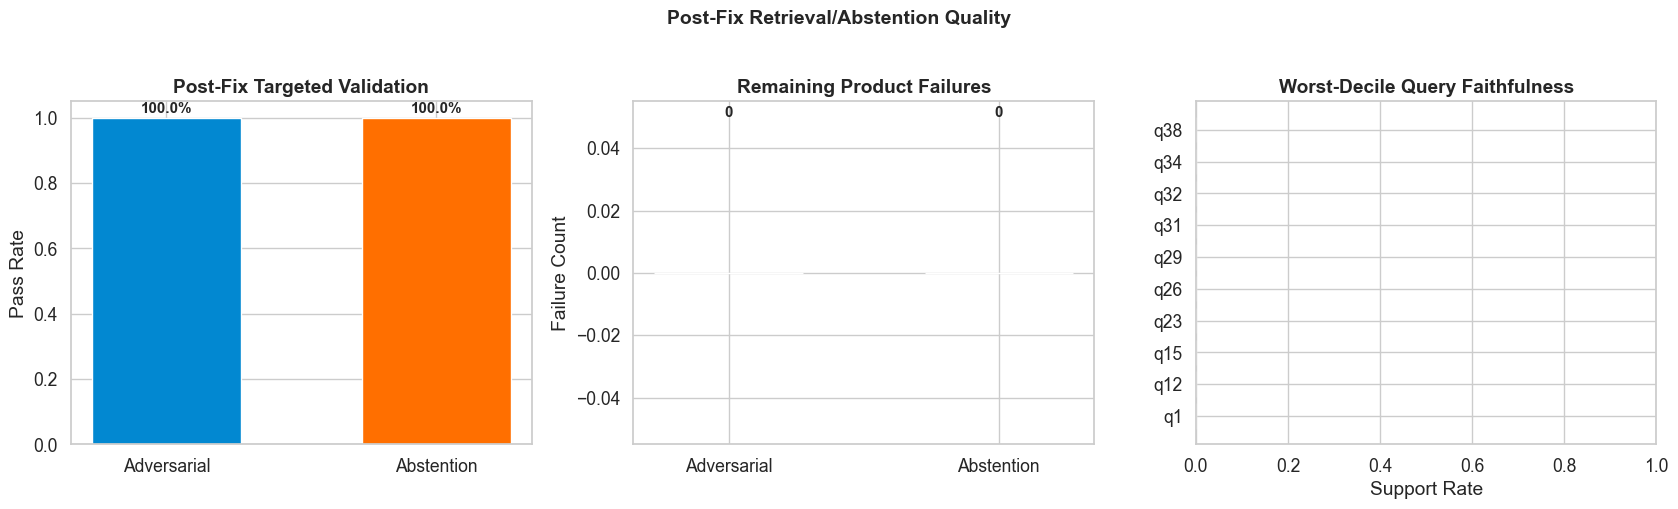

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Targeted validation pass rates ---
labels = ["Adversarial", "Abstention"]
pass_rates = [post_validation["adversarial"]["pass_rate"], post_validation["abstention"]["pass_rate"]]
bars = axes[0].bar(labels, pass_rates, color=[PAL[4], PAL[0]], edgecolor="white", width=0.55)
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.015, f"{b.get_height():.1%}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Pass Rate")
axes[0].set_title("Post-Fix Targeted Validation", fontweight="bold")

# --- Remaining failures by suite ---
fails_adv = post_validation["adversarial"]["count"] - post_validation["adversarial"]["passed"]
fails_abs = post_validation["abstention"]["count"] - post_validation["abstention"]["passed"]
axes[1].bar(["Adversarial", "Abstention"], [fails_adv, fails_abs], color=[PAL[6], PAL[5]], edgecolor="white", width=0.55)
axes[1].set_ylabel("Failure Count")
axes[1].set_title("Remaining Product Failures", fontweight="bold")
for i, v in enumerate([fails_adv, fails_abs]):
    axes[1].text(i, v + 0.05, str(v), ha="center", fontsize=11, fontweight="bold")

# --- Worst-decile query faithfulness ---
worst = pd.DataFrame(faith["worst_decile_queries"])
worst = worst.sort_values("support_rate", ascending=True)
axes[2].barh(worst["query_id"], worst["support_rate"], color=PAL[1], edgecolor="white")
axes[2].set_xlim(0, 1.0)
axes[2].set_xlabel("Support Rate")
axes[2].set_title("Worst-Decile Query Faithfulness", fontweight="bold")

fig.suptitle("Post-Fix Retrieval/Abstention Quality", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_retrieval.png", dpi=180, bbox_inches="tight")
plt.show()


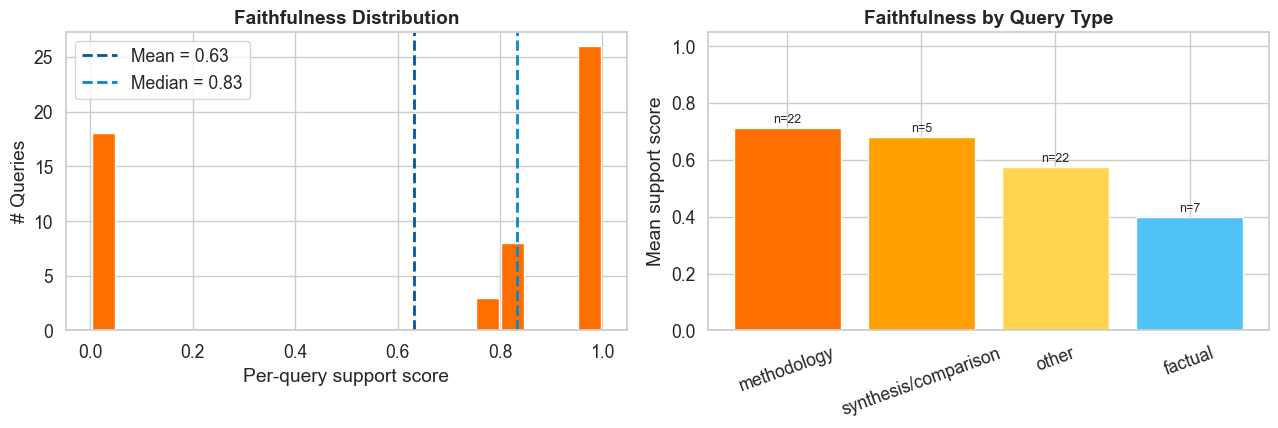

In [3]:
# Query-level faithfulness distribution from post-fix judge output
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

scores = df_query_scores["support_rate"].to_numpy() if not df_query_scores.empty else np.array([])
if scores.size:
    axes[0].hist(scores, bins=np.linspace(0, 1, 21), color=PAL[0], edgecolor="white", rwidth=0.9)
    axes[0].axvline(scores.mean(), color=PAL[5], ls="--", lw=2, label=f"Mean = {scores.mean():.2f}")
    axes[0].axvline(np.median(scores), color=PAL[4], ls="--", lw=2, label=f"Median = {np.median(scores):.2f}")
    axes[0].legend()
axes[0].set_xlabel("Per-query support score")
axes[0].set_ylabel("# Queries")
axes[0].set_title("Faithfulness Distribution", fontweight="bold")

strata = pd.DataFrame([
    {"stratum": k, "mean": v["bootstrap_ci_95"]["mean"], "n": v["n_queries"]}
    for k, v in faith["by_stratum"].items()
]).sort_values("mean", ascending=False)
axes[1].bar(strata["stratum"], strata["mean"], color=PAL[:len(strata)], edgecolor="white")
for i, row in strata.reset_index(drop=True).iterrows():
    axes[1].text(i, row["mean"] + 0.02, f"n={int(row['n'])}", ha="center", fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Mean support score")
axes[1].set_title("Faithfulness by Query Type", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("figures/fig_latency.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 2. Post-Fix Faithfulness Evaluation (Strict Grounding + Coverage Tradeoff)


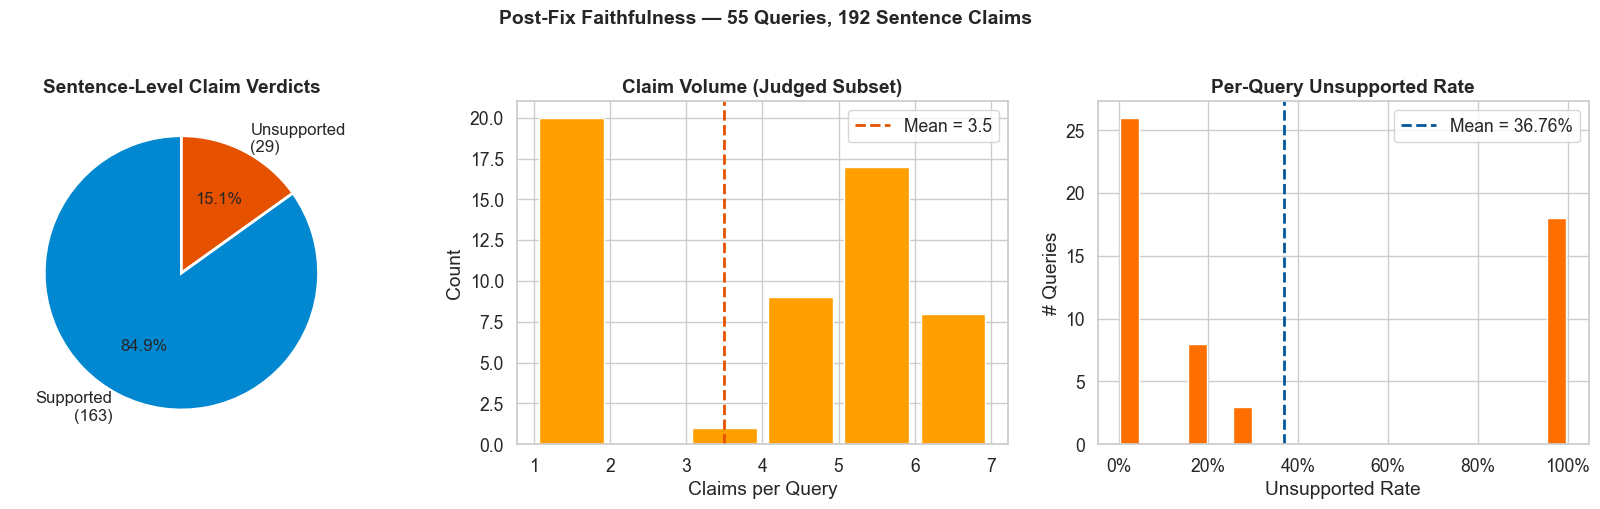

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Sentence-level supported vs unsupported claims (subset with judge claim rows)
axes[0].pie([n_sup, n_unsup], labels=[f"Supported\n({n_sup})", f"Unsupported\n({n_unsup})"],
            colors=[PAL[4], PAL[6]], autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 12}, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Sentence-Level Claim Verdicts", fontweight="bold")

# Claims per query (only where sentence-level claims are available)
qcounts = df_claims.groupby("query_id").size() if not df_claims.empty else pd.Series(dtype=int)
if not qcounts.empty:
    axes[1].hist(qcounts, bins=range(1, int(qcounts.max()) + 2), color=PAL[1], edgecolor="white", rwidth=0.85)
    axes[1].axvline(qcounts.mean(), color=PAL[6], ls="--", lw=2, label=f"Mean = {qcounts.mean():.1f}")
    axes[1].legend()
axes[1].set_xlabel("Claims per Query")
axes[1].set_ylabel("Count")
axes[1].set_title("Claim Volume (Judged Subset)", fontweight="bold")

# Unsupported rate per query
if not df_claims.empty:
    unsup_rate = df_claims.groupby("query_id")["supported"].apply(lambda s: 1 - s.mean())
    axes[2].hist(unsup_rate, bins=np.arange(0, 1.05, 0.05), color=PAL[0], edgecolor="white", rwidth=0.85)
    axes[2].axvline(unsup_rate.mean(), color=PAL[5], ls="--", lw=2, label=f"Mean = {unsup_rate.mean():.2%}")
    axes[2].legend()
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_xlabel("Unsupported Rate")
axes[2].set_ylabel("# Queries")
axes[2].set_title("Per-Query Unsupported Rate", fontweight="bold")

fig.suptitle(f"Post-Fix Faithfulness — {len(df_query_scores)} Queries, {len(df_claims)} Sentence Claims", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_faithfulness.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 3. Post-Fix M/S/A Distributions (Complete-Feature Subset)

Distributions are computed from claims with non-null `msa_M`, `msa_S`, and `msa_A` values.

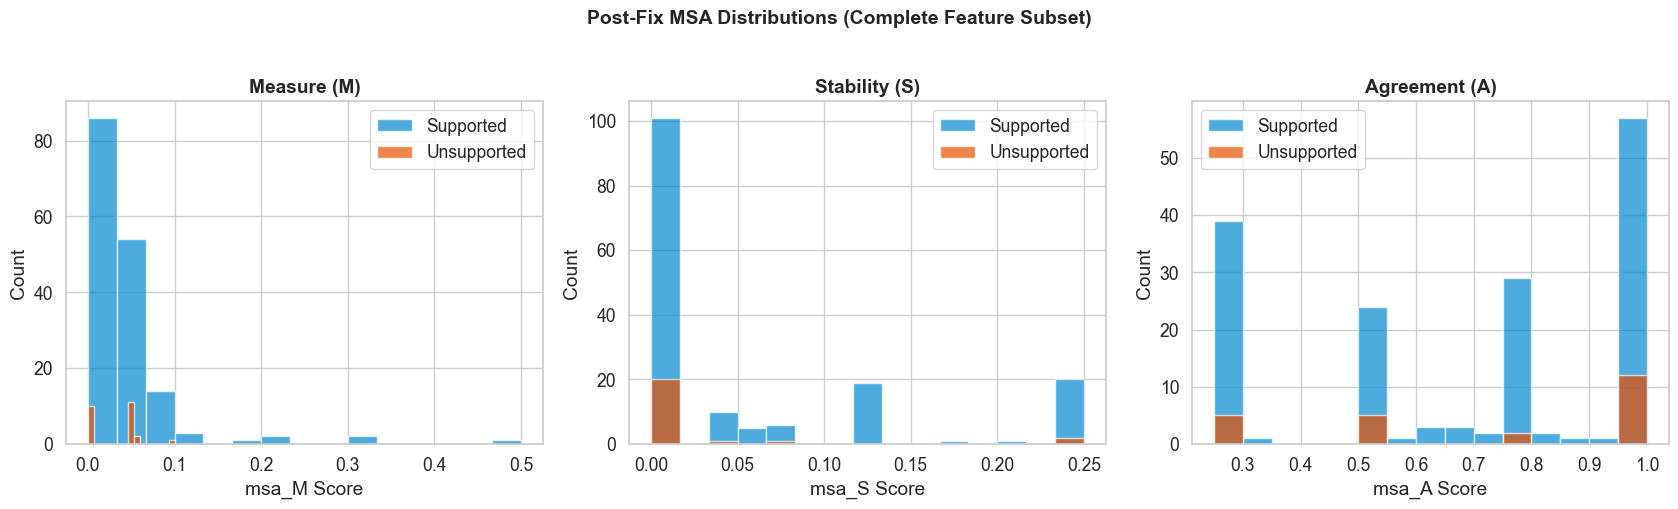

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
components = [("msa_M", "Measure (M)"), ("msa_S", "Stability (S)"), ("msa_A", "Agreement (A)")]

for ax, (col, title) in zip(axes, components):
    for label, color in [("supported", PAL[4]), ("unsupported", PAL[6])]:
        subset = df_claim_complete[df_claim_complete["label"] == label][col]
        if not subset.empty:
            ax.hist(subset, bins=15, alpha=0.7, color=color, label=label.capitalize(), edgecolor="white")
    ax.set_xlabel(f"{col} Score")
    ax.set_ylabel("Count")
    ax.set_title(title, fontweight="bold")
    ax.legend()

fig.suptitle("Post-Fix MSA Distributions (Complete Feature Subset)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_msa_distributions.png", dpi=180, bbox_inches="tight")
plt.show()


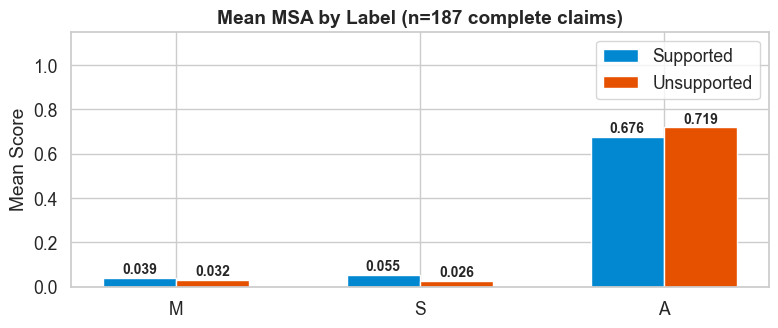

In [6]:
# MSA mean summary table (post-fix complete-feature subset)
means = (
    df_claim_complete.groupby("label")[["msa_M", "msa_S", "msa_A"]]
    .mean()
    .reindex(["supported", "unsupported"])
)

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(3); w = 0.3
sup_vals = means.loc["supported"].to_numpy()
unsup_vals = means.loc["unsupported"].to_numpy()
ax.bar(x - w/2, sup_vals, w, label="Supported", color=PAL[4], edgecolor="white")
ax.bar(x + w/2, unsup_vals, w, label="Unsupported", color=PAL[6], edgecolor="white")
for i, (s, u) in enumerate(zip(sup_vals, unsup_vals)):
    ax.text(i - w/2, s + 0.02, f"{s:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + w/2, u + 0.02, f"{u:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["M", "S", "A"])
ax.set_ylabel("Mean Score"); ax.set_ylim(0, 1.15)
ax.set_title(f"Mean MSA by Label (n={len(df_claim_complete)} complete claims)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_msa_means.png", dpi=180, bbox_inches="tight")
plt.show()


---
## 4. Leakage-Aware Calibration & Split Sensitivity

Calibration metrics come from `calibration_robustness.json` and explicitly include the complete-feature sample-size caveat.

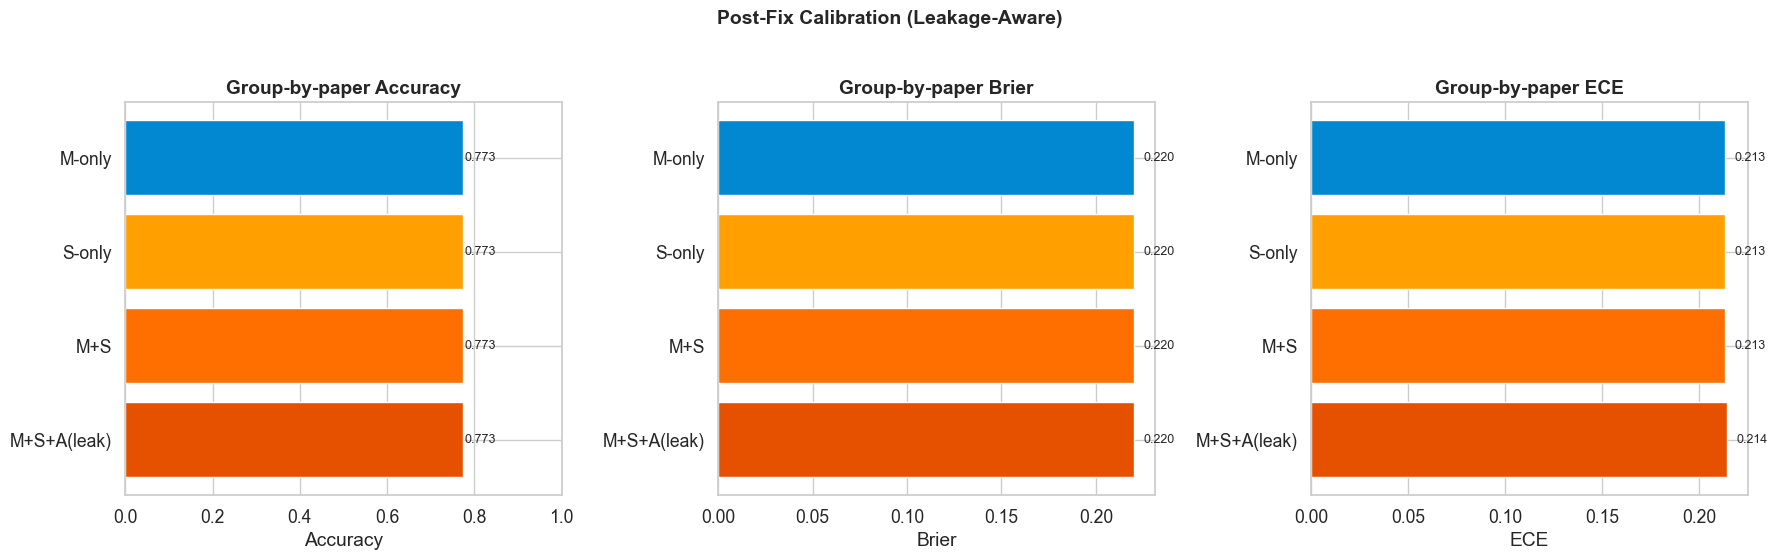

Model,Accuracy,Brier,ECE,ROC-AUC,PR-AUC
M-only,0.773,0.220,0.213,0.342,0.754
S-only,0.773,0.220,0.213,0.429,0.758
M+S,0.773,0.220,0.213,0.415,0.779
M+S+A(leak),0.773,0.220,0.214,0.629,0.815


In [7]:
models_order = ["M-only", "S-only", "M+S", "M+S+A(leak)"]
rows = []
for m in calib["splits"]["group_by_paper"]["models"]:
    rows.append({
        "Model": m["model"],
        "Accuracy": m["accuracy"]["mean"],
        "Brier": m["brier"]["mean"],
        "ECE": m["ece"]["mean"],
        "ROC-AUC": m["roc_auc"]["mean"],
        "PR-AUC": m["pr_auc"]["mean"],
    })
df_ab = pd.DataFrame(rows)
df_ab["Model"] = pd.Categorical(df_ab["Model"], categories=models_order, ordered=True)
df_ab = df_ab.sort_values("Model")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
colors_bar = [PAL[4], PAL[1], PAL[0], PAL[6]]

bars = axes[0].barh(df_ab["Model"], df_ab["Accuracy"], color=colors_bar, edgecolor="white")
for b in bars:
    axes[0].text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f"{b.get_width():.3f}", va="center", fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Group-by-paper Accuracy", fontweight="bold")
axes[0].invert_yaxis()

bars = axes[1].barh(df_ab["Model"], df_ab["Brier"], color=colors_bar, edgecolor="white")
for b in bars:
    axes[1].text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f"{b.get_width():.3f}", va="center", fontsize=9)
axes[1].set_xlabel("Brier")
axes[1].set_title("Group-by-paper Brier", fontweight="bold")
axes[1].invert_yaxis()

bars = axes[2].barh(df_ab["Model"], df_ab["ECE"], color=colors_bar, edgecolor="white")
for b in bars:
    axes[2].text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f"{b.get_width():.3f}", va="center", fontsize=9)
axes[2].set_xlabel("ECE")
axes[2].set_title("Group-by-paper ECE", fontweight="bold")
axes[2].invert_yaxis()

fig.suptitle("Post-Fix Calibration (Leakage-Aware)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

display(df_ab.style.format({"Accuracy": "{:.3f}", "Brier": "{:.3f}", "ECE": "{:.3f}", "ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"}).set_caption("Calibration Metrics (group-by-paper)").hide(axis="index"))


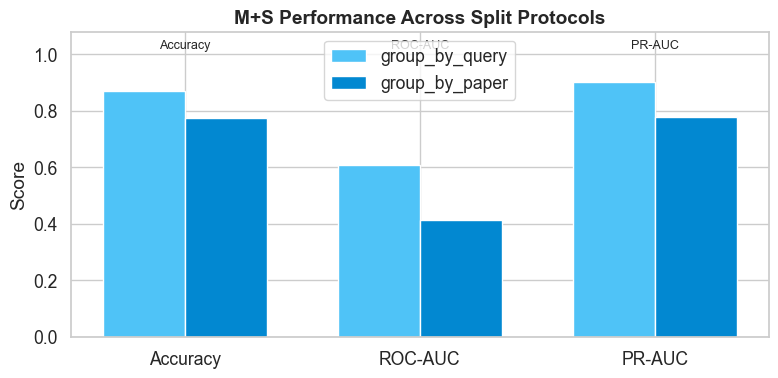

Split,Accuracy,Brier,ECE,ROC-AUC,PR-AUC
group_by_query,0.872,0.112,0.032,0.607,0.901
group_by_paper,0.773,0.220,0.213,0.415,0.779


In [8]:
# Compare split sensitivity (group-by-query vs group-by-paper) for M+S
split_rows = []
for split_name, split in calib["splits"].items():
    m = next(x for x in split["models"] if x["model"] == "M+S")
    split_rows.append({
        "Split": split_name,
        "Accuracy": m["accuracy"]["mean"],
        "Brier": m["brier"]["mean"],
        "ECE": m["ece"]["mean"],
        "ROC-AUC": m["roc_auc"]["mean"],
        "PR-AUC": m["pr_auc"]["mean"],
    })
df_split = pd.DataFrame(split_rows)

fig, ax = plt.subplots(figsize=(8, 4))
metrics = ["Accuracy", "ROC-AUC", "PR-AUC"]
x = np.arange(len(metrics)); w = 0.35
for i, row in df_split.iterrows():
    vals = [row[m] for m in metrics]
    ax.bar(x + (i-0.5)*w, vals, width=w, label=row["Split"], edgecolor="white", color=PAL[3+i])
for i in range(len(metrics)):
    ax.text(i, 1.02, metrics[i], ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("M+S Performance Across Split Protocols", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_weights.png", dpi=180, bbox_inches="tight")
plt.show()

display(df_split.style.format({"Accuracy": "{:.3f}", "Brier": "{:.3f}", "ECE": "{:.3f}", "ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"}).hide(axis="index"))


---
## 5. Inter-Annotator Agreement (Fresh Claim Sheet)

Claim IAA below uses the fresh sample sheet; annotator-B is rubric-generated and should be presented as synthetic QA, not independent human adjudication.


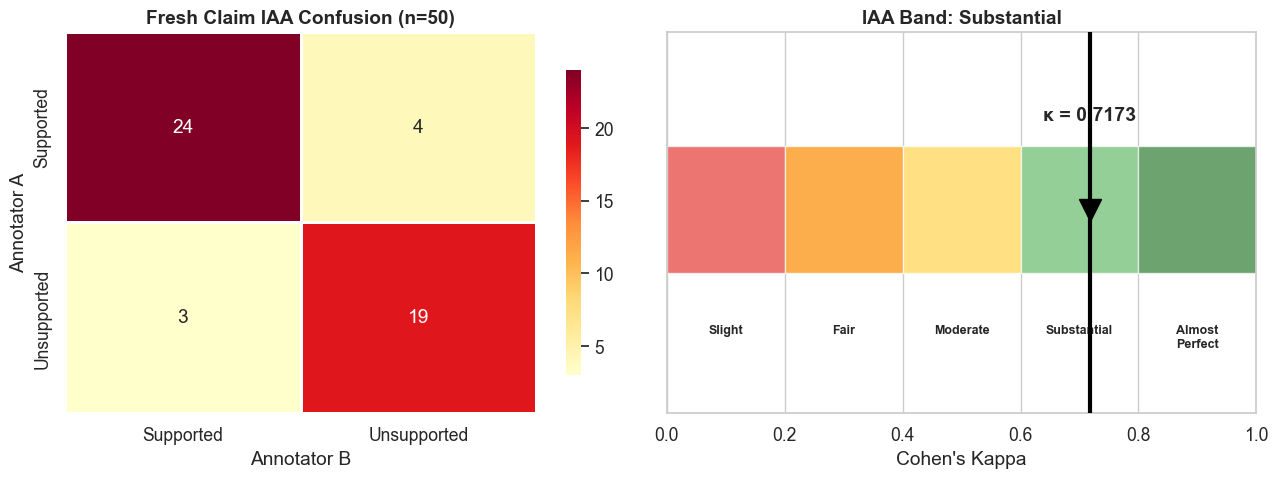

Agreement: 43/50 (86.0%)
Cohen's kappa: 0.7173 — substantial
Disclosure: annotator-B generated by rubric script (not independent second human)


In [9]:
cm = iaa["confusion_matrix"]
conf_mat = np.array([[cm["sup_sup"], cm["sup_unsup"]],
                     [cm["unsup_sup"], cm["unsup_unsup"]]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["Supported", "Unsupported"],
            yticklabels=["Supported", "Unsupported"],
            ax=axes[0], cbar_kws={"shrink": 0.8}, linewidths=2, linecolor="white")
axes[0].set_xlabel("Annotator B"); axes[0].set_ylabel("Annotator A")
axes[0].set_title(f"Fresh Claim IAA Confusion (n={iaa['n']})", fontweight="bold")

# Kappa gauge
kappa = iaa["cohens_kappa"]
kappa_ranges = [(0, 0.20, "Slight"), (0.20, 0.40, "Fair"),
                (0.40, 0.60, "Moderate"), (0.60, 0.80, "Substantial"),
                (0.80, 1.00, "Almost\nPerfect")]
colors_kappa = ["#E53935", "#FB8C00", "#FFD54F", "#66BB6A", "#2E7D32"]

for (lo, hi, lbl), col in zip(kappa_ranges, colors_kappa):
    axes[1].barh(0, hi - lo, left=lo, height=0.5, color=col, edgecolor="white", alpha=0.7)
    axes[1].text((lo + hi)/2, -0.45, lbl, ha="center", va="top", fontsize=9, fontweight="bold")

axes[1].axvline(kappa, color="black", lw=3, zorder=5)
axes[1].plot(kappa, 0, marker="v", color="black", markersize=16, zorder=6)
axes[1].text(kappa, 0.35, f"κ = {kappa:.4f}", ha="center", fontsize=14, fontweight="bold")

axes[1].set_xlim(0, 1); axes[1].set_ylim(-0.8, 0.7)
axes[1].set_xlabel("Cohen's Kappa"); axes[1].set_yticks([])
axes[1].set_title(f"IAA Band: {iaa['interpretation'].title()}", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_iaa.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Agreement: {iaa['agreement_count']}/{iaa['n']} ({iaa['agreement_pct']}%)")
print(f"Cohen's kappa: {kappa:.4f} — {iaa['interpretation']}")
print(f"Disclosure: {iaa['source_note']}")


---
## 6. Public Research Mode — Provider Coverage & Relevance Proxy

Live API behavior across providers; this section is informative but separate from uploaded-corpus post-fix validation.

Public search evaluation: 20 queries, 200 total results



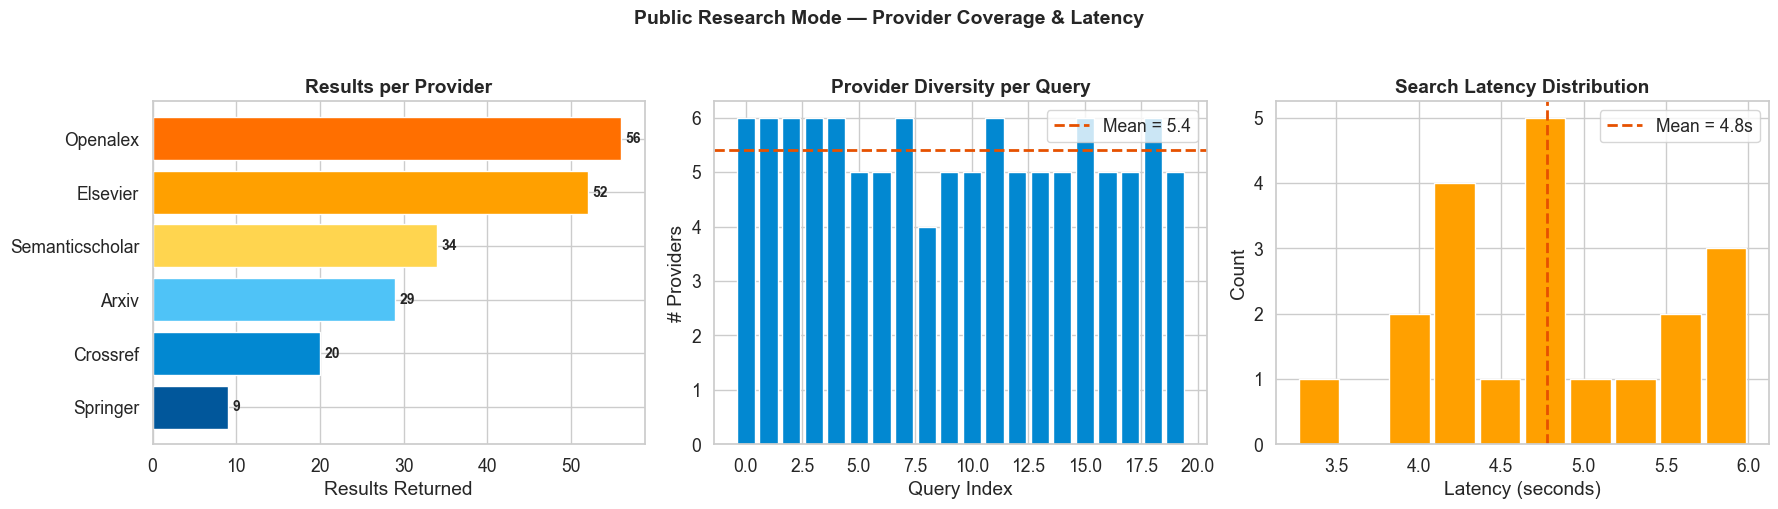

In [10]:
print(f"Public search evaluation: {len(pub_data)} queries, {sum(r['result_count'] for r in pub_data)} total results\n")

# --- Provider coverage ---
all_providers_pub = set()
provider_counts = Counter()
provider_per_query = []
for r in pub_data:
    providers_in_q = set()
    for res in r["results"]:
        src = (res.get("source") or "unknown").lower()
        provider_counts[src] += 1
        providers_in_q.add(src)
    all_providers_pub.update(providers_in_q)
    provider_per_query.append(len(providers_in_q))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sorted_providers = sorted(provider_counts.items(), key=lambda x: -x[1])
prov_names = [p[0].title() for p in sorted_providers]
prov_vals  = [p[1] for p in sorted_providers]
prov_colors = [PAL[i % len(PAL)] for i in range(len(sorted_providers))]
bars = axes[0].barh(prov_names, prov_vals, color=prov_colors, edgecolor="white")
for b in bars:
    axes[0].text(b.get_width() + 0.5, b.get_y() + b.get_height()/2, str(int(b.get_width())), va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Results Returned"); axes[0].invert_yaxis()
axes[0].set_title("Results per Provider", fontweight="bold")

axes[1].bar(range(len(provider_per_query)), provider_per_query, color=PAL[4], edgecolor="white")
axes[1].axhline(np.mean(provider_per_query), color=PAL[6], ls="--", lw=2, label=f"Mean = {np.mean(provider_per_query):.1f}")
axes[1].set_xlabel("Query Index"); axes[1].set_ylabel("# Providers")
axes[1].set_title("Provider Diversity per Query", fontweight="bold")
axes[1].legend()

latencies = [r["latency_s"] for r in pub_data]
axes[2].hist(latencies, bins=10, color=PAL[1], edgecolor="white", rwidth=0.9)
axes[2].axvline(np.mean(latencies), color=PAL[6], ls="--", lw=2, label=f"Mean = {np.mean(latencies):.1f}s")
axes[2].set_xlabel("Latency (seconds)"); axes[2].set_ylabel("Count")
axes[2].set_title("Search Latency Distribution", fontweight="bold")
axes[2].legend()

fig.suptitle("Public Research Mode — Provider Coverage & Latency", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_public_providers.png", dpi=180, bbox_inches="tight")
plt.show()


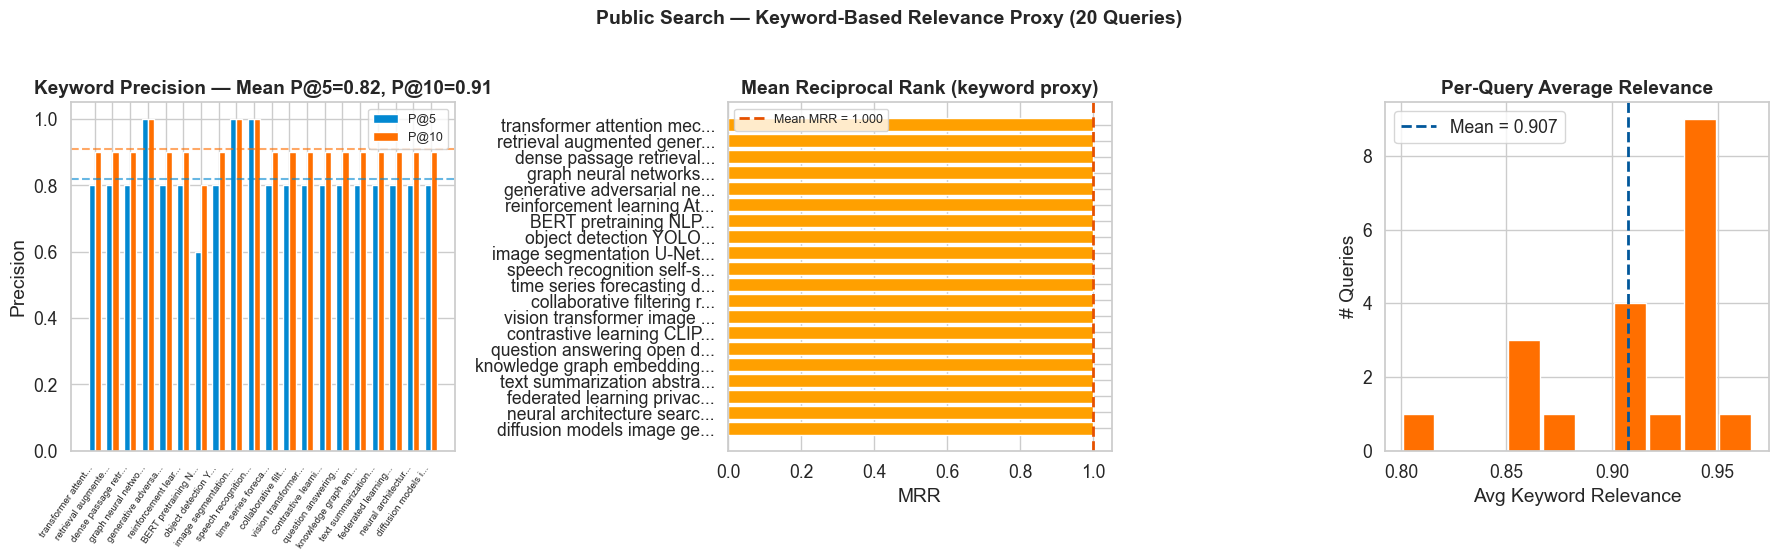


Public Search Relevance Summary:
  Mean Precision@5:  0.820
  Mean Precision@10: 0.910
  Mean MRR:          1.000
  Mean Relevance:    0.907


In [11]:
import re as _re

def _keyword_relevance(query: str, title: str, abstract: str) -> float:
    """Proxy relevance: fraction of query keywords found in title+abstract."""
    stop = {"the","and","for","with","that","this","from","into","using","how","what","why","does","can"}
    q_toks = {t for t in _re.findall(r"[a-z0-9]+", query.lower()) if len(t) > 2 and t not in stop}
    if not q_toks:
        return 0.0
    text = f"{title} {abstract}".lower()
    return sum(1 for t in q_toks if t in text) / len(q_toks)

# Compute proxy relevance for every result
all_relevances = []
per_query_precision = []
per_query_data = []

for r in pub_data:
    query = r["query"]
    rels = []
    for res in r["results"]:
        title = res.get("title", "") or ""
        abstract = res.get("summary", "") or ""
        rel = _keyword_relevance(query, title, abstract)
        rels.append(rel)
        all_relevances.append({"query": query, "title": title[:60], "source": res.get("source","?"), "relevance": rel})
    # Precision@K: fraction of results with relevance > threshold
    p_at_5 = sum(1 for r in rels[:5] if r >= 0.5) / 5 if len(rels) >= 5 else 0
    p_at_10 = sum(1 for r in rels[:10] if r >= 0.5) / max(1, min(10, len(rels)))
    mrr = 0.0
    for rank, rel in enumerate(rels, 1):
        if rel >= 0.5:
            mrr = 1.0 / rank
            break
    per_query_data.append({
        "query": query, "p@5": p_at_5, "p@10": p_at_10, "mrr": mrr,
        "avg_rel": np.mean(rels) if rels else 0, "n_results": len(rels)
    })

df_pq = pd.DataFrame(per_query_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Precision@5 and @10
x = np.arange(len(df_pq)); w = 0.35
axes[0].bar(x - w/2, df_pq["p@5"],  w, label="P@5",  color=PAL[4], edgecolor="white")
axes[0].bar(x + w/2, df_pq["p@10"], w, label="P@10", color=PAL[0], edgecolor="white")
axes[0].axhline(df_pq["p@5"].mean(), color=PAL[4], ls="--", lw=1.5, alpha=0.6)
axes[0].axhline(df_pq["p@10"].mean(), color=PAL[0], ls="--", lw=1.5, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels([q[:18]+"..." for q in df_pq["query"]], rotation=55, ha="right", fontsize=7)
axes[0].set_ylabel("Precision"); axes[0].set_ylim(0, 1.05)
axes[0].set_title(f"Keyword Precision — Mean P@5={df_pq['p@5'].mean():.2f}, P@10={df_pq['p@10'].mean():.2f}", fontweight="bold")
axes[0].legend(fontsize=9)

# MRR
bars = axes[1].barh(df_pq["query"].str[:25]+"...", df_pq["mrr"], color=PAL[1], edgecolor="white")
axes[1].axvline(df_pq["mrr"].mean(), color=PAL[6], ls="--", lw=2,
                label=f"Mean MRR = {df_pq['mrr'].mean():.3f}")
axes[1].set_xlabel("MRR"); axes[1].invert_yaxis()
axes[1].set_title("Mean Reciprocal Rank (keyword proxy)", fontweight="bold")
axes[1].legend(fontsize=9)

# Average relevance distribution
axes[2].hist(df_pq["avg_rel"], bins=10, color=PAL[0], edgecolor="white", rwidth=0.9)
axes[2].axvline(df_pq["avg_rel"].mean(), color=PAL[5], ls="--", lw=2,
                label=f"Mean = {df_pq['avg_rel'].mean():.3f}")
axes[2].set_xlabel("Avg Keyword Relevance"); axes[2].set_ylabel("# Queries")
axes[2].set_title("Per-Query Average Relevance", fontweight="bold")
axes[2].legend()

fig.suptitle("Public Search — Keyword-Based Relevance Proxy (20 Queries)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_public_relevance.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nPublic Search Relevance Summary:")
print(f"  Mean Precision@5:  {df_pq['p@5'].mean():.3f}")
print(f"  Mean Precision@10: {df_pq['p@10'].mean():.3f}")
print(f"  Mean MRR:          {df_pq['mrr'].mean():.3f}")
print(f"  Mean Relevance:    {df_pq['avg_rel'].mean():.3f}")

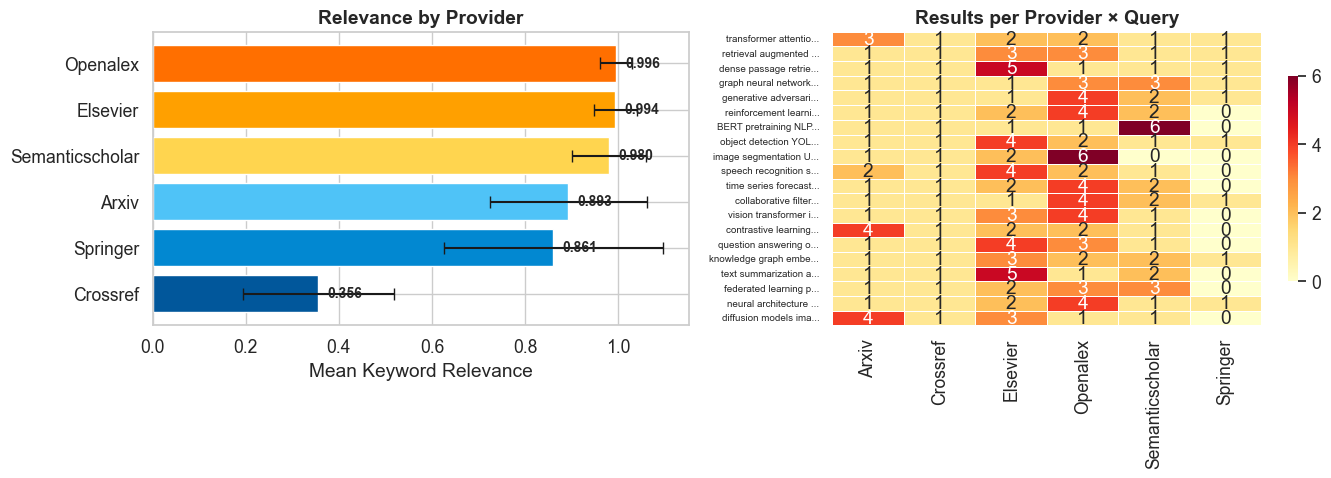

Provider,Mean Relevance,Results,Std
openalex,0.996,56,0.033
elsevier,0.994,52,0.046
semanticscholar,0.980,34,0.080
arxiv,0.893,29,0.169
springer,0.861,9,0.236
crossref,0.356,20,0.162


In [12]:
# Provider-level relevance breakdown
df_all_rel = pd.DataFrame(all_relevances)
provider_rel = df_all_rel.groupby("source")["relevance"].agg(["mean", "count", "std"]).reset_index()
provider_rel.columns = ["Provider", "Mean Relevance", "Results", "Std"]
provider_rel = provider_rel.sort_values("Mean Relevance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Provider-level mean relevance
bars = axes[0].barh(provider_rel["Provider"].str.title(), provider_rel["Mean Relevance"],
                     xerr=provider_rel["Std"], color=PAL[:len(provider_rel)], edgecolor="white",
                     capsize=4)
for b, val in zip(bars, provider_rel["Mean Relevance"]):
    axes[0].text(b.get_width() + 0.02, b.get_y() + b.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Mean Keyword Relevance"); axes[0].invert_yaxis()
axes[0].set_title("Relevance by Provider", fontweight="bold")

# Heatmap: query vs provider availability
query_provider_matrix = []
short_queries = [q[:20]+"..." for q in [r["query"] for r in pub_data]]
for r in pub_data:
    row_providers = Counter(res.get("source", "?") for res in r["results"])
    query_provider_matrix.append(row_providers)

all_prov_names = sorted(all_providers_pub)
matrix = np.zeros((len(pub_data), len(all_prov_names)))
for i, row in enumerate(query_provider_matrix):
    for j, prov in enumerate(all_prov_names):
        matrix[i][j] = row.get(prov, 0)

sns.heatmap(matrix, xticklabels=[p.title() for p in all_prov_names],
            yticklabels=short_queries, cmap="YlOrRd", annot=True, fmt=".0f",
            ax=axes[1], linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.7})
axes[1].set_title("Results per Provider × Query", fontweight="bold")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("figures/fig_public_provider_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

display(provider_rel.style.format({
    "Mean Relevance": "{:.3f}", "Std": "{:.3f}", "Results": "{:.0f}"
}).set_caption("Provider-Level Keyword Relevance").hide(axis="index"))

---
## 7. Combined Post-Fix Summary Dashboard

This combines targeted validation, strict-grounding faithfulness, fresh IAA, cross-corpus generalization, and calibration at a glance.


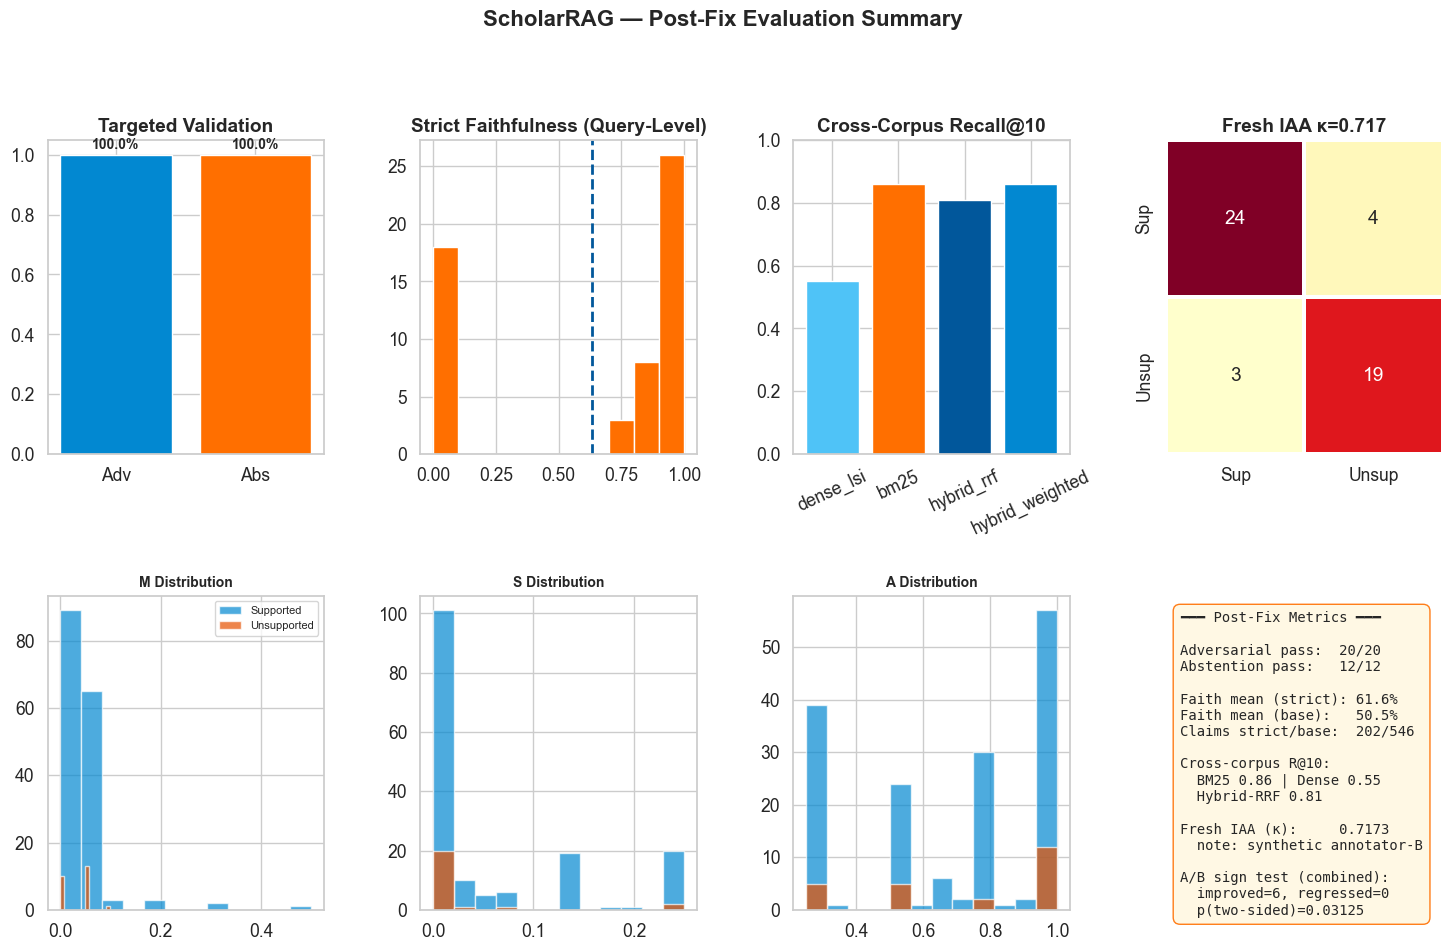

In [13]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)

# (0,0) Targeted validation pass rates
ax1 = fig.add_subplot(gs[0, 0])
vals = [post_validation['adversarial']['pass_rate'], post_validation['abstention']['pass_rate']]
ax1.bar(['Adv', 'Abs'], vals, color=[PAL[4], PAL[0]], edgecolor='white')
for i, v in enumerate(vals):
    ax1.text(i, v + 0.02, f"{v:.1%}", ha='center', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1.05); ax1.set_title('Targeted Validation', fontweight='bold')

# (0,1) Strict-grounding query-level faithfulness
ax2 = fig.add_subplot(gs[0, 1])
fs = df_query_scores['support_rate'].to_numpy()
ax2.hist(fs, bins=np.linspace(0, 1, 11), color=PAL[0], edgecolor='white')
ax2.axvline(fs.mean(), color=PAL[5], ls='--', lw=2)
ax2.set_title('Strict Faithfulness (Query-Level)', fontweight='bold')

# (0,2) Cross-corpus recall@10
ax3 = fig.add_subplot(gs[0, 2])
cc_modes = ['dense_lsi', 'bm25', 'hybrid_rrf', 'hybrid_weighted']
cc_modes = [m for m in cc_modes if m in cross['metrics']]
cc_r10 = [cross['metrics'][m]['recall@10']['mean'] for m in cc_modes]
ax3.bar(cc_modes, cc_r10, color=[PAL[3], PAL[0], PAL[5], PAL[4]][:len(cc_modes)], edgecolor='white')
ax3.set_ylim(0, 1.0); ax3.set_title('Cross-Corpus Recall@10', fontweight='bold')
ax3.tick_params(axis='x', rotation=25)

# (0,3) Fresh IAA
ax4 = fig.add_subplot(gs[0, 3])
cm = iaa['confusion_matrix']
conf_mat = np.array([[cm['sup_sup'], cm['sup_unsup']], [cm['unsup_sup'], cm['unsup_unsup']]])
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='YlOrRd', xticklabels=['Sup', 'Unsup'], yticklabels=['Sup', 'Unsup'], ax=ax4, cbar=False, linewidths=1.5, linecolor='white')
ax4.set_title(f"Fresh IAA κ={iaa['cohens_kappa']:.3f}", fontweight='bold')

# (1,0:2) M/S/A distributions
components = [('msa_M', 'M'), ('msa_S', 'S'), ('msa_A', 'A')]
for i, (col, title) in enumerate(components):
    ax = fig.add_subplot(gs[1, i])
    for label, color in [('supported', PAL[4]), ('unsupported', PAL[6])]:
        subset = df_claim_complete[df_claim_complete['label'] == label][col]
        if not subset.empty:
            ax.hist(subset, bins=12, alpha=0.7, color=color, label=label.capitalize(), edgecolor='white')
    ax.set_title(f"{title} Distribution", fontweight='bold', fontsize=10)
    if i == 0:
        ax.legend(fontsize=8)

# (1,3) Key metrics text
ax5 = fig.add_subplot(gs[1, 3])
ax5.axis('off')
combined_sig = sig['validation_mcnemar']['combined']
metrics_text = (
    f"━━━ Post-Fix Metrics ━━━\n\n"
    f"Adversarial pass:  {post_validation['adversarial']['passed']}/{post_validation['adversarial']['count']}\n"
    f"Abstention pass:   {post_validation['abstention']['passed']}/{post_validation['abstention']['count']}\n\n"
    f"Faith mean (strict): {faith['overall']['query_level_bootstrap_ci_95']['mean']:.1%}\n"
    f"Faith mean (base):   {faith_base['overall']['query_level_bootstrap_ci_95']['mean']:.1%}\n"
    f"Claims strict/base:  {faith['overall']['n_claims']}/{faith_base['overall']['n_claims']}\n\n"
    f"Cross-corpus R@10:\n"
    f"  BM25 {cross['metrics']['bm25']['recall@10']['mean']:.2f} | Dense {cross['metrics']['dense_lsi']['recall@10']['mean']:.2f}\n"
    f"  Hybrid-RRF {cross['metrics']['hybrid_rrf']['recall@10']['mean']:.2f}\n\n"
    f"Fresh IAA (κ):     {iaa['cohens_kappa']:.4f}\n"
    f"  note: synthetic annotator-B\n\n"
    f"A/B sign test (combined):\n"
    f"  improved={combined_sig['n_improved']}, regressed={combined_sig['n_regressed']}\n"
    f"  p(two-sided)={combined_sig['p_value_two_sided']:.5f}"
)
ax5.text(0.05, 0.95, metrics_text, transform=ax5.transAxes, fontsize=10,
         va='top', ha='left', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8E1', edgecolor='#FF6F00', alpha=0.9))

fig.suptitle('ScholarRAG — Post-Fix Evaluation Summary', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('figures/fig_summary_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()


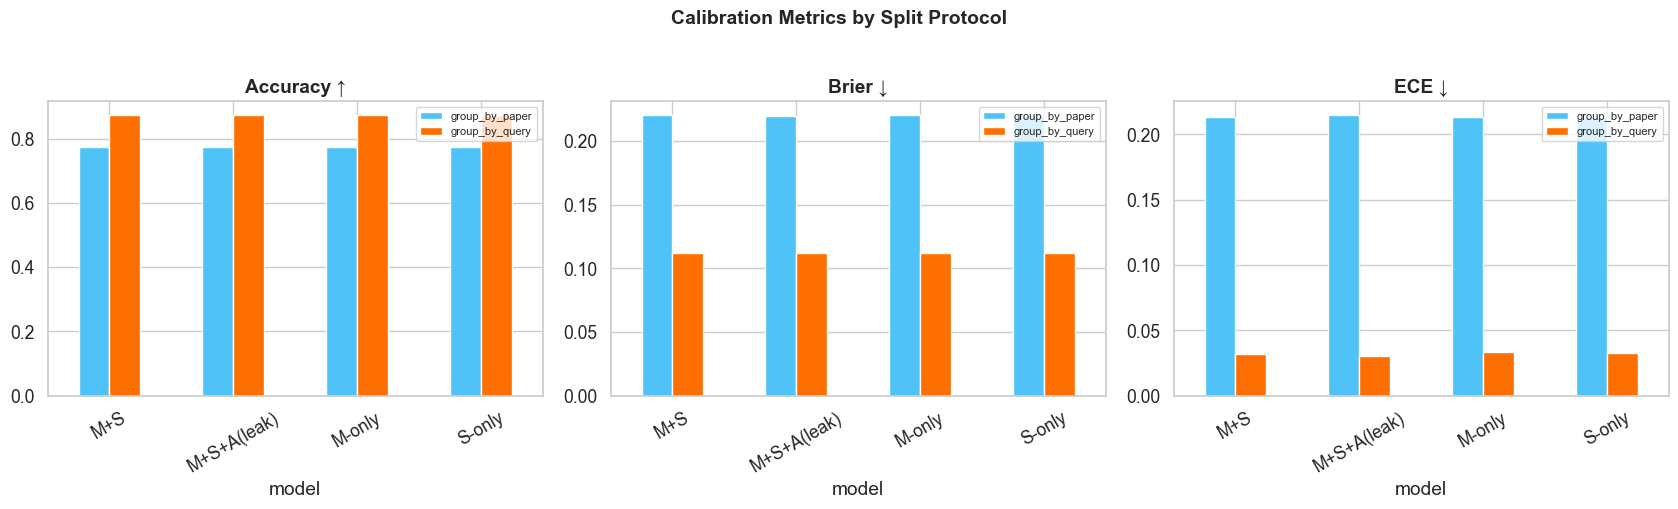

In [14]:
# Split protocol comparison for all calibration models
rows = []
for split_name, split in calib['splits'].items():
    for m in split['models']:
        rows.append({
            'split': split_name,
            'model': m['model'],
            'accuracy': m['accuracy']['mean'],
            'brier': m['brier']['mean'],
            'ece': m['ece']['mean'],
        })
df_split_models = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric, title in zip(axes, ['accuracy', 'brier', 'ece'], ['Accuracy ↑', 'Brier ↓', 'ECE ↓']):
    pivot = df_split_models.pivot(index='model', columns='split', values=metric)
    pivot.plot(kind='bar', ax=ax, color=[PAL[3], PAL[0]], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

fig.suptitle('Calibration Metrics by Split Protocol', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_train_vs_test.png', dpi=180, bbox_inches='tight')
plt.show()


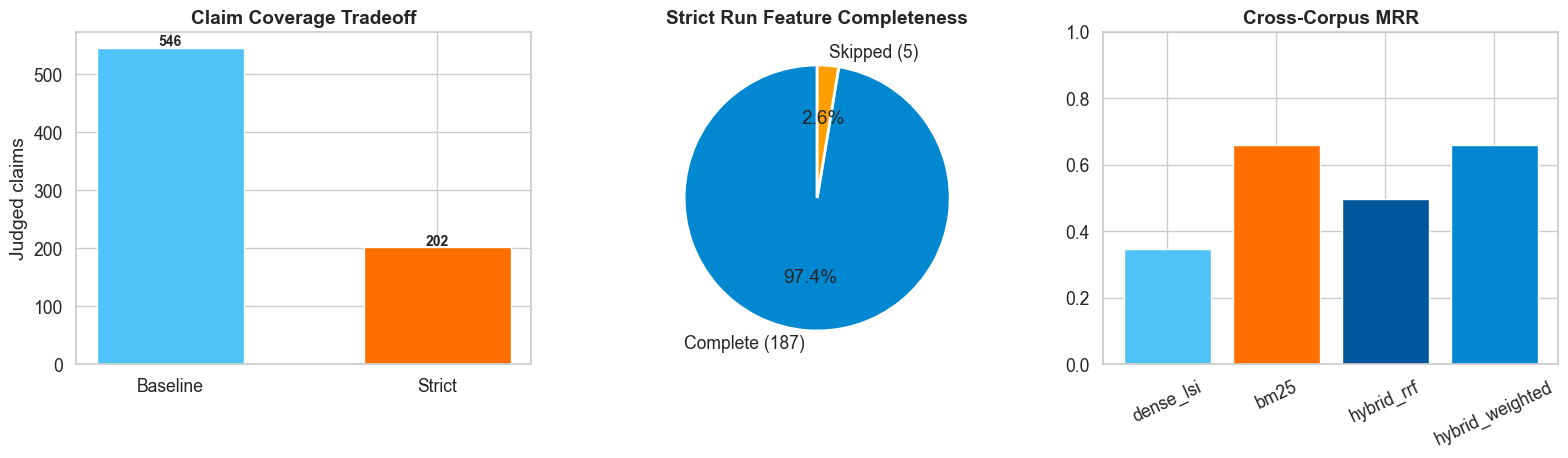

Strict query mean support: 0.616
Baseline query mean support: 0.505
Strict claims: 202 (baseline: 546)
Cross-corpus R@10 (BM25 vs Hybrid-RRF): 0.860 vs 0.810


In [15]:
# Dataset composition + strict-grounding tradeoff + cross-corpus MRR
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Strict vs baseline tradeoff
axes[0].bar(['Baseline', 'Strict'], [faith_base['overall']['n_claims'], faith['overall']['n_claims']],
            color=[PAL[3], PAL[0]], edgecolor='white', width=0.55)
axes[0].set_ylabel('Judged claims')
axes[0].set_title('Claim Coverage Tradeoff', fontweight='bold')
for i, v in enumerate([faith_base['overall']['n_claims'], faith['overall']['n_claims']]):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10, fontweight='bold')

# Complete vs skipped features
axes[1].pie([calib['n_claims_complete'], calib['n_claims_skipped_incomplete_features']],
            labels=[f"Complete ({calib['n_claims_complete']})", f"Skipped ({calib['n_claims_skipped_incomplete_features']})"],
            colors=[PAL[4], PAL[1]], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Strict Run Feature Completeness', fontweight='bold')

# Cross-corpus MRR by mode
modes = ['dense_lsi', 'bm25', 'hybrid_rrf', 'hybrid_weighted']
modes = [m for m in modes if m in cross['metrics']]
mrr_vals = [cross['metrics'][m]['mrr']['mean'] for m in modes]
axes[2].bar(modes, mrr_vals, color=[PAL[3], PAL[0], PAL[5], PAL[4]][:len(modes)], edgecolor='white')
axes[2].set_ylim(0, 1.0)
axes[2].set_title('Cross-Corpus MRR', fontweight='bold')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('figures/fig_dataset.png', dpi=180, bbox_inches='tight')
plt.show()

print(f"Strict query mean support: {faith['overall']['query_level_bootstrap_ci_95']['mean']:.3f}")
print(f"Baseline query mean support: {faith_base['overall']['query_level_bootstrap_ci_95']['mean']:.3f}")
print(f"Strict claims: {faith['overall']['n_claims']} (baseline: {faith_base['overall']['n_claims']})")
print(f"Cross-corpus R@10 (BM25 vs Hybrid-RRF): {cross['metrics']['bm25']['recall@10']['mean']:.3f} vs {cross['metrics']['hybrid_rrf']['recall@10']['mean']:.3f}")


---
## 8. Confidence Score Distribution (If Present in Post-Fix Artifacts)

Plots only if citation-level confidence is available in the post-fix judge output.

In [16]:
# Extract confidence scores if present in post-fix judge citations
conf_scores = []
for d in judge_raw.get('details', []):
    for cit in d.get('citations', []):
        if 'confidence_percent' in cit:
            conf_scores.append(cit['confidence_percent'])
        elif 'confidence' in cit and isinstance(cit['confidence'], (int, float)):
            conf_scores.append(cit['confidence'] * 100 if cit['confidence'] <= 1 else cit['confidence'])

if conf_scores:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(conf_scores, bins=20, color=PAL[0], edgecolor='white', rwidth=0.9)
    axes[0].axvline(np.mean(conf_scores), color=PAL[5], ls='--', lw=2, label=f"Mean = {np.mean(conf_scores):.1f}%")
    axes[0].set_xlabel('Confidence (%)'); axes[0].set_ylabel('Count')
    axes[0].set_title('Per-Citation Confidence Distribution', fontweight='bold')
    axes[0].legend()

    query_confs = {}
    for d in judge_raw.get('details', []):
        q = d.get('query', '')[:40]
        for cit in d.get('citations', []):
            c = cit.get('confidence_percent', cit.get('confidence', None))
            if isinstance(c, (int, float)):
                c = c * 100 if c <= 1 else c
                query_confs.setdefault(q, []).append(c)

    means = sorted(query_confs.items(), key=lambda x: np.mean(x[1]))
    show = means[:5] + means[-5:]
    labels = [s[0][:35] + '...' for s in show]
    data = [s[1] for s in show]
    bp = axes[1].boxplot(data, vert=False, patch_artist=True)
    colors_box = [PAL[6]] * 5 + [PAL[4]] * 5
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_yticklabels(labels, fontsize=7)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Top-5 / Bottom-5 Queries by Confidence', fontweight='bold')

    plt.tight_layout()
    plt.savefig('figures/fig_confidence_dist.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('No per-citation confidence scores found in post-fix judge results.')


No per-citation confidence scores found in post-fix judge results.


---
## 9. Corrected Post-Fix Metrics Table (Presentation-Ready)

Includes strict-grounding tradeoffs, fresh IAA disclosure, cross-corpus generalization, and significance tests.


In [17]:
summary_table = pd.DataFrame([
    {'Category': 'Targeted Validation', 'Metric': 'Adversarial Pass Rate', 'Value': f"{post_validation['adversarial']['passed']}/{post_validation['adversarial']['count']} ({post_validation['adversarial']['pass_rate']:.1%})"},
    {'Category': 'Targeted Validation', 'Metric': 'Abstention Pass Rate',  'Value': f"{post_validation['abstention']['passed']}/{post_validation['abstention']['count']} ({post_validation['abstention']['pass_rate']:.1%})"},

    {'Category': 'Faithfulness (Baseline)', 'Metric': 'Query-level Mean', 'Value': f"{faith_base['overall']['query_level_bootstrap_ci_95']['mean']:.1%}"},
    {'Category': 'Faithfulness (Strict)', 'Metric': 'Query-level Mean', 'Value': f"{faith['overall']['query_level_bootstrap_ci_95']['mean']:.1%}"},
    {'Category': 'Faithfulness (Strict)', 'Metric': 'Query-level 95% CI', 'Value': f"[{faith['overall']['query_level_bootstrap_ci_95']['lo']:.1%}, {faith['overall']['query_level_bootstrap_ci_95']['hi']:.1%}]"},
    {'Category': 'Faithfulness Tradeoff', 'Metric': 'Judged Claims (Base → Strict)', 'Value': f"{faith_base['overall']['n_claims']} → {faith['overall']['n_claims']}"},
    {'Category': 'Faithfulness (Strict)', 'Metric': 'Claim Support Rate', 'Value': f"{faith['overall']['claim_support_rate']:.1%}"},

    {'Category': 'Calibration (Strict)', 'Metric': 'Raw Claims', 'Value': str(calib['n_claims_raw'])},
    {'Category': 'Calibration (Strict)', 'Metric': 'Labeled Claims', 'Value': str(calib['n_claims_labeled'])},
    {'Category': 'Calibration (Strict)', 'Metric': 'Complete M/S/A Claims', 'Value': str(calib['n_claims_complete'])},
    {'Category': 'Calibration (Strict)', 'Metric': 'Skipped Incomplete', 'Value': str(calib['n_claims_skipped_incomplete_features'])},
    {'Category': 'Calibration (Strict)', 'Metric': 'Group-by-paper M+S Accuracy', 'Value': f"{headline['post_fix_calibration']['group_by_paper_M+S']['accuracy']:.3f}"},
    {'Category': 'Calibration (Strict)', 'Metric': 'Group-by-paper M+S Macro-F1', 'Value': f"{headline['post_fix_calibration']['group_by_paper_M+S']['f1_macro']:.3f}"},
    {'Category': 'Calibration (Strict)', 'Metric': 'Group-by-paper M+S Brier', 'Value': f"{headline['post_fix_calibration']['group_by_paper_M+S']['brier']:.3f}"},
    {'Category': 'Calibration (Strict)', 'Metric': 'Group-by-paper M+S ECE', 'Value': f"{headline['post_fix_calibration']['group_by_paper_M+S']['ece']:.3f}"},

    {'Category': 'Fresh IAA (Claims)', 'Metric': "Cohen's Kappa", 'Value': f"{iaa_fresh['claim_sheet']['cohen_kappa']:.4f}"},
    {'Category': 'Fresh IAA (Claims)', 'Metric': 'Agreement', 'Value': f"{iaa_fresh['claim_sheet']['agreement']:.1%}"},
    {'Category': 'Fresh IAA (Disclosure)', 'Metric': 'Annotator-B Source', 'Value': 'Rubric-generated (synthetic), not independent human'},
    {'Category': 'Fresh IAA (Retrieval)', 'Metric': "Kappa (3-class / binary)", 'Value': f"{iaa_fresh['retrieval_sheet']['cohen_kappa_3class']:.4f} / {iaa_fresh['retrieval_sheet']['cohen_kappa_binary']:.4f}"},

    {'Category': 'Cross-Corpus (SciFact-lite)', 'Metric': 'Dense Recall@10 / MRR', 'Value': f"{cross['metrics']['dense_lsi']['recall@10']['mean']:.3f} / {cross['metrics']['dense_lsi']['mrr']['mean']:.3f}"},
    {'Category': 'Cross-Corpus (SciFact-lite)', 'Metric': 'BM25 Recall@10 / MRR', 'Value': f"{cross['metrics']['bm25']['recall@10']['mean']:.3f} / {cross['metrics']['bm25']['mrr']['mean']:.3f}"},
    {'Category': 'Cross-Corpus (SciFact-lite)', 'Metric': 'Hybrid-RRF Recall@10 / MRR', 'Value': f"{cross['metrics']['hybrid_rrf']['recall@10']['mean']:.3f} / {cross['metrics']['hybrid_rrf']['mrr']['mean']:.3f}"},
    {'Category': 'Cross-Corpus (SciFact-lite)', 'Metric': 'Hybrid-Weighted Recall@10 / MRR', 'Value': f"{cross['metrics']['hybrid_weighted']['recall@10']['mean']:.3f} / {cross['metrics']['hybrid_weighted']['mrr']['mean']:.3f}"},

    {'Category': 'Significance', 'Metric': 'Validation sign test (combined, two-sided p)', 'Value': f"{sig['validation_mcnemar']['combined']['p_value_two_sided']:.5f}"},
    {'Category': 'Significance', 'Metric': 'Faithfulness Wilcoxon (one-sided p)', 'Value': f"{sig['faithfulness_wilcoxon']['p_value_one_sided_improvement']:.5f}"},

    {'Category': 'Legacy 634-claim A Fix', 'Metric': 'A mean supported (old → clean)', 'Value': f"{clean_a['msa_A_old_by_label']['mean']['supported']:.3f} → {clean_a['msa_A_clean_by_label']['mean']['supported']:.3f}"},
    {'Category': 'Legacy 634-claim A Fix', 'Metric': 'A mean unsupported (old → clean)', 'Value': f"{clean_a['msa_A_old_by_label']['mean']['unsupported']:.3f} → {clean_a['msa_A_clean_by_label']['mean']['unsupported']:.3f}"},
])

display(summary_table.style.set_properties(**{'text-align': 'left'}).set_caption(
    'ScholarRAG — Corrected Post-Fix Evaluation Metrics (Strict Grounding + Cross-Corpus + Significance)'
).hide(axis='index'))

print('Updated figures saved under Evaluation/figures/ and post-fix detail files under Evaluation/data/post_fix/.')


Category,Metric,Value
Targeted Validation,Adversarial Pass Rate,20/20 (100.0%)
Targeted Validation,Abstention Pass Rate,12/12 (100.0%)
Faithfulness (Baseline),Query-level Mean,50.5%
Faithfulness (Strict),Query-level Mean,61.6%
Faithfulness (Strict),Query-level 95% CI,"[48.9%, 73.2%]"
Faithfulness Tradeoff,Judged Claims (Base → Strict),546 → 202
Faithfulness (Strict),Claim Support Rate,85.6%
Calibration (Strict),Raw Claims,247
Calibration (Strict),Labeled Claims,192
Calibration (Strict),Complete M/S/A Claims,187


Updated figures saved under Evaluation/figures/ and post-fix detail files under Evaluation/data/post_fix/.
